# Preprocessing QC summary


In [10]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

# --- set your file path here ---
csv_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/preprocessed/18_02_2026_minLenght110_QScore20/bbduk_summary_20260218_104832.csv"   # <-- change

df = pd.read_csv(csv_path)
df.head()


,sample_id,sample_name,sample_label,input_fastq,output_fastq,output_size_bytes,bbduk_version,reads_in,bases_in,reads_out,bases_out,reads_removed,bases_removed,reads_qtrimmed,bases_qtrimmed,runtime_s
0,GFB-64245,DMF5CDR3bGIG012xnegative,GFB-64245_DMF5CDR3bGIG012xnegative,/cluster/project/reddy/katja/data/raw/P3481_LU...,/cluster/project/reddy/katja/NGS_pipeline/data...,732680693,39.33,12405242,1860786300,6272245,849227320,6132997,1011558980,10621114,1011558980,33.818856
1,GFB-64245,DMF5CDR3bGIG012xnegative,GFB-64245_DMF5CDR3bGIG012xnegative,/cluster/project/reddy/katja/data/raw/P3481_LU...,/cluster/project/reddy/katja/NGS_pipeline/data...,1579564831,39.33,22501072,3375160800,14287677,1996245130,8213395,1378915670,16465268,1378915670,72.713861
2,GFB-64246,DMF5CDR3bGIG032xnegative,GFB-64246_DMF5CDR3bGIG032xnegative,/cluster/project/reddy/katja/data/raw/P3481_LU...,/cluster/project/reddy/katja/NGS_pipeline/data...,290131365,39.33,5440897,816134550,2581526,357660333,2859371,458474217,4239675,458474217,14.827283
3,GFB-64246,DMF5CDR3bGIG032xnegative,GFB-64246_DMF5CDR3bGIG032xnegative,/cluster/project/reddy/katja/data/raw/P3481_LU...,/cluster/project/reddy/katja/NGS_pipeline/data...,731081459,39.33,13012629,1951894350,6941055,971814726,6071574,980079624,9517724,980079624,35.310259
4,GFB-64247,DMF5CDR3bGIG042xnegative,GFB-64247_DMF5CDR3bGIG042xnegative,/cluster/project/reddy/katja/data/raw/P3481_LU...,/cluster/project/reddy/katja/NGS_pipeline/data...,1010927753,39.33,13432672,2014900800,8689118,1249263626,4743554,765637174,7553527,765637174,45.949610


In [11]:
# Ensure numeric cols are numeric (in case they were read as strings)
num_cols = [
    "output_size_bytes",
    "reads_in","bases_in","reads_out","bases_out",
    "reads_removed","bases_removed",
    "reads_qtrimmed","bases_qtrimmed",
    "runtime_s"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Derive run_id from the input_fastq path: ".../run1-1000M/..." -> "run1-1000M"
def extract_run_id(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"/(run\d+-[^/]+)/", str(p))
    return m.group(1) if m else np.nan

df["run_id"] = df["input_fastq"].apply(extract_run_id)

# Optional: lane from filename "..._L001_..." -> "L001"
def extract_lane(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"_L(\d{3})_", str(p))
    return f"L{m.group(1)}" if m else np.nan

df["lane"] = df["input_fastq"].apply(extract_lane)

# Helpful QC metrics (guard against division by zero)
df["retention_reads_pct"] = 100 * df["reads_out"] / df["reads_in"]
df["retention_bases_pct"] = 100 * df["bases_out"] / df["bases_in"]
df["avg_read_len_in"] = df["bases_in"] / df["reads_in"]
df["avg_read_len_out"] = df["bases_out"] / df["reads_out"]
df["throughput_reads_per_s"] = df["reads_in"] / df["runtime_s"]
df["qtrim_share_of_removed_reads_pct"] = 100 * df["reads_qtrimmed"] / df["reads_removed"].replace(0, np.nan)

df[["sample_id","sample_name","run_id","lane","reads_in","reads_out","retention_reads_pct","runtime_s"]].head()


,sample_id,sample_name,run_id,lane,reads_in,reads_out,retention_reads_pct,runtime_s
0,GFB-64245,DMF5CDR3bGIG012xnegative,NaN,L001,12405242,6272245,50.561247,33.818856
1,GFB-64245,DMF5CDR3bGIG012xnegative,NaN,L002,22501072,14287677,63.497761,72.713861
2,GFB-64246,DMF5CDR3bGIG032xnegative,NaN,L001,5440897,2581526,47.446699,14.827283
3,GFB-64246,DMF5CDR3bGIG032xnegative,NaN,L002,13012629,6941055,53.340912,35.310259
4,GFB-64247,DMF5CDR3bGIG042xnegative,NaN,L001,13432672,8689118,64.686445,45.949610


In [12]:
group_cols = ["sample_id", "sample_name", "sample_label"]

sample_summary = (
    df.groupby(group_cols, dropna=False)
      .agg(
          n_rows=("input_fastq","count"),
          n_runs=("run_id", pd.Series.nunique),
          n_lanes=("lane", pd.Series.nunique),
          reads_in=("reads_in","sum"),
          reads_out=("reads_out","sum"),
          reads_removed=("reads_removed","sum"),
          reads_qtrimmed=("reads_qtrimmed","sum"),
          bases_in=("bases_in","sum"),
          bases_out=("bases_out","sum"),
          bases_removed=("bases_removed","sum"),
          bases_qtrimmed=("bases_qtrimmed","sum"),
          output_size_bytes=("output_size_bytes","sum"),
          runtime_s=("runtime_s","sum"),
      )
      .reset_index()
)

# Derived metrics on the aggregates
sample_summary["retention_reads_pct"] = 100 * sample_summary["reads_out"] / sample_summary["reads_in"]
sample_summary["retention_bases_pct"] = 100 * sample_summary["bases_out"] / sample_summary["bases_in"]
sample_summary["avg_read_len_in"] = sample_summary["bases_in"] / sample_summary["reads_in"]
sample_summary["avg_read_len_out"] = sample_summary["bases_out"] / sample_summary["reads_out"]
sample_summary["throughput_reads_per_s"] = sample_summary["reads_in"] / sample_summary["runtime_s"]

sample_summary.sort_values("reads_in", ascending=False).head(10)


,sample_id,sample_name,sample_label,n_rows,n_runs,n_lanes,reads_in,reads_out,reads_removed,reads_qtrimmed,...,bases_out,bases_removed,bases_qtrimmed,output_size_bytes,runtime_s,retention_reads_pct,retention_bases_pct,avg_read_len_in,avg_read_len_out,throughput_reads_per_s
18,GFB-64263,DMF5CDR3borilib,GFB-64263_DMF5CDR3borilib,2,0,2,63429054,30326070,33102984,50868919,...,4207192936,5307165164,5307165164,3565954836,171.123079,47.811008,44.219409,150.0,138.731888,370663.351993
17,GFB-64262,DMF5CDR3bDRG042xpositive,GFB-64262_DMF5CDR3bDRG042xpositive,2,0,2,48744321,37040837,11703484,22718765,...,5368775711,1942872439,1942872439,3901115669,185.223778,75.990056,73.427709,150.0,144.942073,263164.489930
2,GFB-64247,DMF5CDR3bGIG042xnegative,GFB-64247_DMF5CDR3bGIG042xnegative,2,0,2,45684103,31921097,13763006,23307730,...,4613281842,2239333608,2239333608,3575866452,165.488180,69.873533,67.321476,150.0,144.521407,276056.591810
0,GFB-64245,DMF5CDR3bGIG012xnegative,GFB-64245_DMF5CDR3bGIG012xnegative,2,0,2,34906314,20559922,14346392,27086382,...,2845472450,2390474650,2390474650,2312245524,106.532718,58.900295,54.344943,150.0,138.398991,327658.157532
3,GFB-64248,DMF5CDR3bGIG052xnegative,GFB-64248_DMF5CDR3bGIG052xnegative,2,0,2,22043894,13088994,8954900,15132263,...,1843995057,1462589043,1462589043,1461449852,69.540651,59.376959,55.767372,150.0,140.881343,316992.918259
15,GFB-64260,DMF5CDR3bGIG052xpositive,GFB-64260_DMF5CDR3bGIG052xpositive,2,0,2,21302932,14039806,7263126,11876641,...,2020417174,1175022626,1175022626,1580890253,73.056739,65.905510,63.228141,150.0,143.906346,291594.345228
4,GFB-64249,DMF5CDR3bDRG012xnegative,GFB-64249_DMF5CDR3bDRG012xnegative,2,0,2,19220198,10386374,8833824,12668865,...,1473848236,1409181464,1409181464,1168378890,55.468884,54.038850,51.121507,150.0,141.902096,346504.142496
12,GFB-64257,DMF5CDR3bGIG012xpositive,GFB-64257_DMF5CDR3bGIG012xpositive,2,0,2,18651963,13155403,5496560,9133570,...,1910709500,887084950,887084950,1478638158,68.852910,70.530930,68.293419,150.0,145.241427,270895.785201
1,GFB-64246,DMF5CDR3bGIG032xnegative,GFB-64246_DMF5CDR3bGIG032xnegative,2,0,2,18453526,9522581,8930945,13757399,...,1329475059,1438553841,1438553841,1021212824,50.137542,51.603043,48.029667,150.0,139.612891,368058.049372
9,GFB-64254,DMF5CDR3bGIG051xpositive,GFB-64254_DMF5CDR3bGIG051xpositive,2,0,2,16597455,9577580,7019875,10256371,...,1374943610,1114674640,1114674640,1095511052,52.359707,57.705112,55.227086,150.0,143.558562,316989.072588


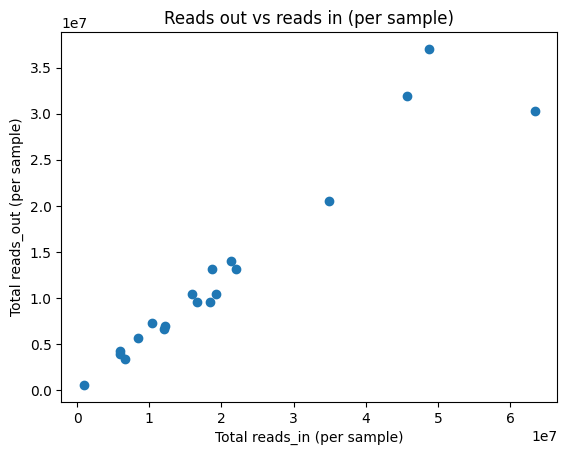

In [13]:
plt.figure()
plt.scatter(sample_summary["reads_in"], sample_summary["reads_out"])
plt.xlabel("Total reads_in (per sample)")
plt.ylabel("Total reads_out (per sample)")
plt.title("Reads out vs reads in (per sample)")
plt.show()


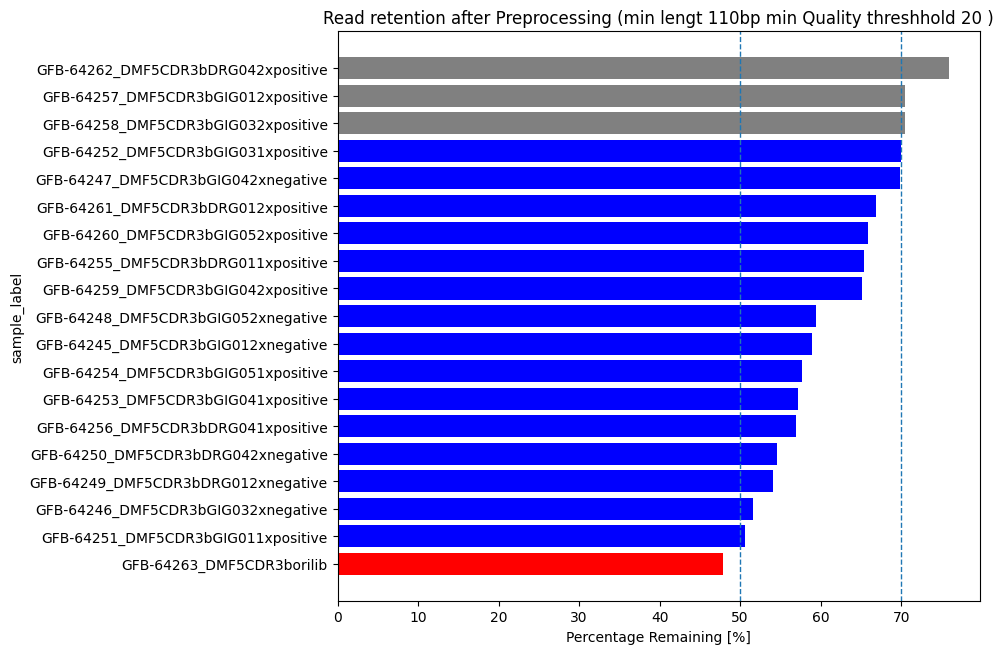

In [16]:
all_samples = sample_summary.sort_values("retention_reads_pct")

colors = [
    "red" if x < 50 else
    "blue" if x < 70 else
    "gray"
    for x in all_samples["retention_reads_pct"]
]

plt.figure(figsize=(10, max(4, 0.35 * len(all_samples))))
plt.barh(all_samples["sample_label"].astype(str),
         all_samples["retention_reads_pct"],
         color=colors)

plt.axvline(50, linestyle="--", linewidth=1)
plt.axvline(70, linestyle="--", linewidth=1)

plt.xlabel("Percentage Remaining [%]")
plt.ylabel("sample_label")
plt.title("Read retention after Preprocessing (min lengt 110bp min Quality threshhold 20 )")
plt.tight_layout()
plt.show()


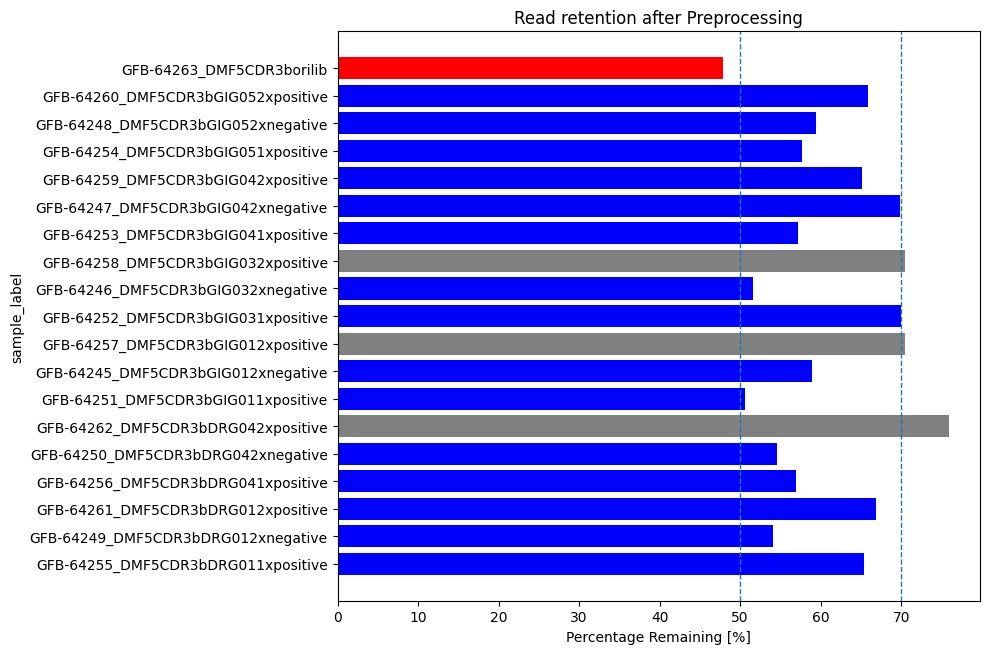

In [15]:
all_samples = sample_summary.sort_values(["sample_name"])

colors = [
    "red" if x < 50 else
    "blue" if x < 70 else
    "gray"
    for x in all_samples["retention_reads_pct"]
]

plt.figure(figsize=(10, max(4, 0.35 * len(all_samples))))
plt.barh(all_samples["sample_label"].astype(str),
         all_samples["retention_reads_pct"],
         color=colors)

plt.axvline(50, linestyle="--", linewidth=1)
plt.axvline(70, linestyle="--", linewidth=1)

plt.xlabel("Percentage Remaining [%]")
plt.ylabel("sample_label")
plt.title("Read retention after Preprocessing")
plt.tight_layout()
plt.show()
